# Extract ERA5 at a Point: The Right Way

Most people never think about what they're actually asking a computer to do.

You need Hs, Tp, and wind speed at one offshore platform. **4°N, 108°E. Natuna Sea. 10 years of hourly data.**

ERA5 gives you that wrapped inside a global grid: **1440 longitudes × 721 latitudes × 87,660 timesteps × 4 variables.**

You want **one longitude. One latitude. All timesteps.**

That's 0.0001% of the data.

The question isn't "how do I open this file."
The question is: **does your code read 0.0001% or 100%?**

Most scripts, including the ones you'll find on Stack Overflow, read the data 100%.
Not because the files are too big. Because the *pattern* is wrong.

This tutorial teaches you the pattern that's right.
By the end, you'll extract a clean, analysis-ready time series
at any point on Earth in under 10 seconds, regardless of file size.

In [3]:
# @title 🚀 Step 0 — Environment setup (run this cell first)
import os
import subprocess
import sys
from pathlib import Path

REPO_URL = "https://github.com/nusawave-labs/extract-point.git"
ERA5_SAMPLE_URL = (
    "https://github.com/nusawave-labs/extract-point/releases/download/v0.1-data/era5_sample.nc"
)
MIN_SAMPLE_BYTES = 50_000_000


def in_colab() -> bool:
    try:
        import google.colab  # noqa: F401
        return True
    except ImportError:
        return False


def download_sample(dest: Path) -> None:
    dest.parent.mkdir(parents=True, exist_ok=True)
    if dest.exists() and dest.stat().st_size >= MIN_SAMPLE_BYTES:
        print(f"Sample data OK: {dest.name} ({dest.stat().st_size / 1e6:.0f} MB)")
        return
    print(f"Downloading {dest.name} …")
    subprocess.check_call(["wget", "-q", "-O", str(dest), ERA5_SAMPLE_URL])


def pip_install(requirements: Path) -> None:
    print(f"Installing dependencies from {requirements.name} …")
    result = subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", "-r", str(requirements)],
        capture_output=True,
        text=True,
    )
    if result.returncode != 0:
        if result.stdout:
            print(result.stdout)
        if result.stderr:
            print(result.stderr)
        raise subprocess.CalledProcessError(
            result.returncode, result.args, result.stdout, result.stderr
        )


def find_repo_root() -> Path:
    candidates = [
        Path.cwd(),
        Path.cwd().parent,
        Path("/content/extract-point"),
        Path.cwd() / "extract-point",
    ]
    for root in candidates:
        if (root / "src" / "extract_utils.py").exists():
            return root.resolve()
    return Path.cwd().resolve()


if in_colab():
    if not Path("extract-point/src/extract_utils.py").exists():
        subprocess.check_call(["git", "clone", "--depth", "1", REPO_URL, "extract-point"])
    os.chdir("extract-point/notebooks")
    pip_install(Path("../requirements-notebook.txt").resolve())

REPO_ROOT = find_repo_root()
DATA_PATH = REPO_ROOT / "data" / "era5_sample.nc"
download_sample(DATA_PATH)
sys.path.insert(0, str((REPO_ROOT / "src").resolve()))

print(f"✅ Environment ready | repo: {REPO_ROOT.name} | data: {DATA_PATH.name}")

Sample data OK: era5_sample.nc (118 MB)
✅ Environment ready | repo: extract-point | data: era5_sample.nc


In [5]:
# ══════════════════════════════════════════════════════════════
#  SETUP — imports, constants (Step 0 must run first)
# ══════════════════════════════════════════════════════════════

import time
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

warnings.filterwarnings("ignore", category=RuntimeWarning)
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.family": "sans-serif",
})

# ── target location ───────────────────────────────────────────
TARGET_LAT = 4.0    # °N  Natuna Sea offshore platform
TARGET_LON = 108.0  # °E
SITE_NAME = "Natuna Sea Platform"

if "DATA_PATH" not in globals() or DATA_PATH is None or not Path(DATA_PATH).exists():
    raise RuntimeError("Run the Step 0 bootstrap cell above first.")

DATA_PATH = Path(DATA_PATH)
if DATA_PATH.stat().st_size < MIN_SAMPLE_BYTES:
    raise FileNotFoundError(
        f"{DATA_PATH} looks like a Git LFS pointer ({DATA_PATH.stat().st_size} bytes).\n"
        "Re-run Step 0 to download the sample from GitHub Releases."
    )

# ── nearest grid indices (used by isel + naive benchmark) ─────
with xr.open_dataset(DATA_PATH) as _ds:
    lat_arr = _ds.latitude.values
    lon_arr = _ds.longitude.values
lat_idx = int(np.abs(lat_arr - TARGET_LAT).argmin())
lon_idx = int(np.abs(lon_arr - TARGET_LON).argmin())

print(f"✅ Ready | data: {DATA_PATH.name} ({DATA_PATH.stat().st_size / 1e6:.1f} MB)")
print(f"   site: {SITE_NAME} ({TARGET_LAT}°N, {TARGET_LON}°E)")
print(f"   nearest grid: lat[{lat_idx}]={lat_arr[lat_idx]:.2f}°N, lon[{lon_idx}]={lon_arr[lon_idx]:.2f}°E")


✅ Ready | data: era5_sample.nc (118.5 MB)
   site: Natuna Sea Platform (4.0°N, 108.0°E)
   nearest grid: lat[19]=4.00°N, lon[19]=108.00°E


### SECTION 1: How Gridded Data Actually Works

#### 1.1 What is a NetCDF file, really?

In [3]:
# NetCDF = labeled N-dimensional array on disk
#
#          time (8760 steps)
#         /
#        /
#       /_________ lat (721 points)
#       |
#       |_________ lon (1440 points)
#
# Each variable (Hs, Tp, wind) = one cube
# You want ONE point → a line through the time axis
# Loading the whole cube for one point = criminal waste


#### 1.2 Lazy vs Eager Loading — The Core Concept

Lazy Loading: "I'll read it when I actually need it"
Eager Loading: "Load everything into RAM right now"

| Method           | Loads to RAM? | Speed to open | Speed to compute |
|------------------|---------------|---------------|------------------|
| pandas read_csv  | Eager — YES   | Fast          | Fast (small data)|
| xarray (default) | Lazy          | Instant       | Fast (on demand) |
| xarray + dask    | Lazy + chunked| Instant       | Parallelized     |
| netCDF4 raw      | Eager         | Slow          | Depends          |

Rule: For files > 500MB — ALWAYS lazy load first.


#### 1.3 Indexing Methods — sel vs isel vs interp

In [9]:
# Three ways to select a point — teach the difference clearly

ds = xr.open_dataset(DATA_PATH)  # lazy by default

# How to find the right index for isel — don't guess!
print(f"Nearest grid point:  lat[{lat_idx}] = {lat_arr[lat_idx]:.2f}°N")
print(f"                     lon[{lon_idx}] = {lon_arr[lon_idx]:.2f}°E")

# METHOD 1: Label-based selection (nearest grid point)
ts_sel = ds["swh"].sel(latitude=TARGET_LAT, longitude=TARGET_LON, method="nearest")

# METHOD 2: Index-based selection (transparent — no magic numbers)
ts_isel = ds["swh"].isel(latitude=lat_idx, longitude=lon_idx)

# METHOD 3: Interpolation (bilinear)
ts_interp = ds["swh"].interp(latitude=TARGET_LAT, longitude=TARGET_LON)

# KEY INSIGHT: sel/isel = lazy (nothing loaded yet)
#              .values or .compute() = triggers actual read


Nearest grid point:  lat[19] = 4.00°N
                     lon[19] = 108.00°E


#### 1.4 Memory Model — What Actually Happens

Think of xarray like a map of a library.
- Opening the dataset = reading the catalog (instant, tiny)
- .sel() = marking a book on the shelf (still lazy)
- .values = physically walking to the shelf and pulling the book

This is why xarray feels "instant to open" —
it hasn't read your 2.3GB file yet.


### SECTION 2: Data Setup

The hands-on tutorial uses **`era5_sample.nc`** (~120 MB, 1 year (2024), 20×20 grid around Natuna Sea).

**Step 0** above downloads it automatically on Colab (via GitHub Releases — no Git LFS, no CDS account). Locally, `git clone` + `git lfs pull` also works.

To regenerate: `python3 scripts/download_era5.py` (requires CDS credentials — see [`data/README.md`](../data/README.md)).


### SECTION 3: The Extraction — Four Methods, One Goal

#### 3.1 Method 1 — Naive (The Wrong Way, for contrast)

In [10]:
# THE WRONG WAY — shown intentionally
# Don't do this with large files

start = time.perf_counter()
ds_eager = xr.open_dataset(DATA_PATH, chunks=None)  # forces eager
hs_wrong = ds_eager["swh"].values  # loads EVERYTHING
point_wrong = hs_wrong[:, lat_idx, lon_idx]  # then slices
elapsed = time.perf_counter() - start

print(f"Loaded full array: {hs_wrong.nbytes / 1e6:.1f} MB")
print(f"Time: {elapsed:.2f}s")
print("❌ Don't do this on a 2GB file — you'd load 2GB for one point")


Loaded full array: 53.4 MB
Time: 0.15s
❌ Don't do this on a 2GB file — you'd load 2GB for one point


#### 3.2 Method 2 — xarray Lazy + .sel() (The Standard Way)

In [11]:
start = time.perf_counter()

ds = xr.open_dataset(DATA_PATH)  # lazy
hs_point = ds["swh"].sel(
    latitude=TARGET_LAT,
    longitude=TARGET_LON,
    method="nearest",
).compute()  # only NOW does it read from disk

elapsed = time.perf_counter() - start
print(f"Extracted {len(hs_point)} timesteps")
print(f"Memory used: {hs_point.nbytes / 1e3:.1f} KB")
print(f"Time: {elapsed:.2f}s ✅")


Extracted 8784 timesteps
Memory used: 35.1 KB
Time: 0.06s ✅


#### 3.3 Method 3 — xarray + Dask (For Very Large Files)

In [12]:
# ── METHOD 3: xarray + Dask (for very large files) ─────────────────────────
# On multi-GB files, chunking lets xarray read time blocks in parallel.
# We run on the teaching sample here; see Section 5 for benchmarks at scale.

import dask  # noqa: F401 — confirm dask is installed

start = time.perf_counter()
ds_dask = xr.open_dataset(DATA_PATH, chunks={"time": 500})

hs_dask = ds_dask["swh"].sel(
    latitude=TARGET_LAT, longitude=TARGET_LON, method="nearest"
).compute()

elapsed = time.perf_counter() - start
print(f"Dask extraction: {len(hs_dask)} timesteps in {elapsed:.2f}s")
print("On files > 1 GB, Dask pays off — see the pre-computed charts in Section 5.")


Dask extraction: 8784 timesteps in 0.16s
On files > 1 GB, Dask pays off — see the pre-computed charts in Section 5.


/tmp/ipykernel_38782/2414601759.py:8: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 500. This could degrade performance. Instead, consider rechunking after loading.
  ds_dask = xr.open_dataset(DATA_PATH, chunks={"time": 500})


💡 When to use Dask:
- File > 1 GB
- Multi-year, multi-variable analysis
- Running on a machine with multiple CPU cores

For single-point extraction from a pre-sliced file,
standard xarray is usually faster (less overhead).


#### 3.4 Method 4 — Interpolation (When Precision Matters)

In [13]:
# Bilinear interpolation — for points between grid cells
INTERP_LAT = TARGET_LAT + 0.12
INTERP_LON = TARGET_LON + 0.37

hs_interp = ds["swh"].interp(
    latitude=INTERP_LAT,
    longitude=INTERP_LON,
    method="linear",
).compute()

diff = np.abs(hs_point.values - hs_interp.values).mean()
print(f"Mean difference (nearest vs interp): {diff:.4f} m")
print("→ For offshore engineering, use interp for site-specific reports")


Mean difference (nearest vs interp): nan m
→ For offshore engineering, use interp for site-specific reports


### SECTION 4: Post-Processing — Clean Output

In [14]:
from extract_utils import extract_point, add_wind_speed, quick_stats

df = extract_point(DATA_PATH, TARGET_LAT, TARGET_LON)
df = add_wind_speed(df)
df["lat"] = TARGET_LAT
df["lon"] = TARGET_LON
df["source"] = "ERA5"

print(df.describe().round(3))
print(f"\nMissing values:\n{df.isna().sum()}")

df.to_csv("natuna_timeseries.csv")
print("\n✅ Saved: natuna_timeseries.csv")


         u10_ms    v10_ms      hs_m      tp_s  wave_dir_deg  swell_hs_m  \
count  8784.000  8784.000  8784.000  8784.000      8784.000    8784.000   
mean     -0.273    -0.243     0.588     5.221       127.958       0.446   
std       3.021     3.691     0.304     2.104       104.871       0.179   
min      -7.640   -10.104     0.127     1.998         0.011       0.011   
25%      -2.719    -3.059     0.346     3.882        28.720       0.311   
50%      -0.446    -0.377     0.522     4.586        95.440       0.422   
75%       2.023     2.498     0.768     5.600       213.907       0.566   
max      11.642     9.937     2.612    11.098       359.632       1.576   

       swell_dir_deg  swell_tp_s  wind_speed_ms  wind_dir_deg     lat     lon  
count       8784.000    8784.000       8784.000      8784.000  8784.0  8784.0  
mean         126.238       4.829          4.249       144.682     4.0   108.0  
std          109.480       1.212          2.197        99.198     0.0     0.0  
min 

#### 4.1 Quick-Look Time Series

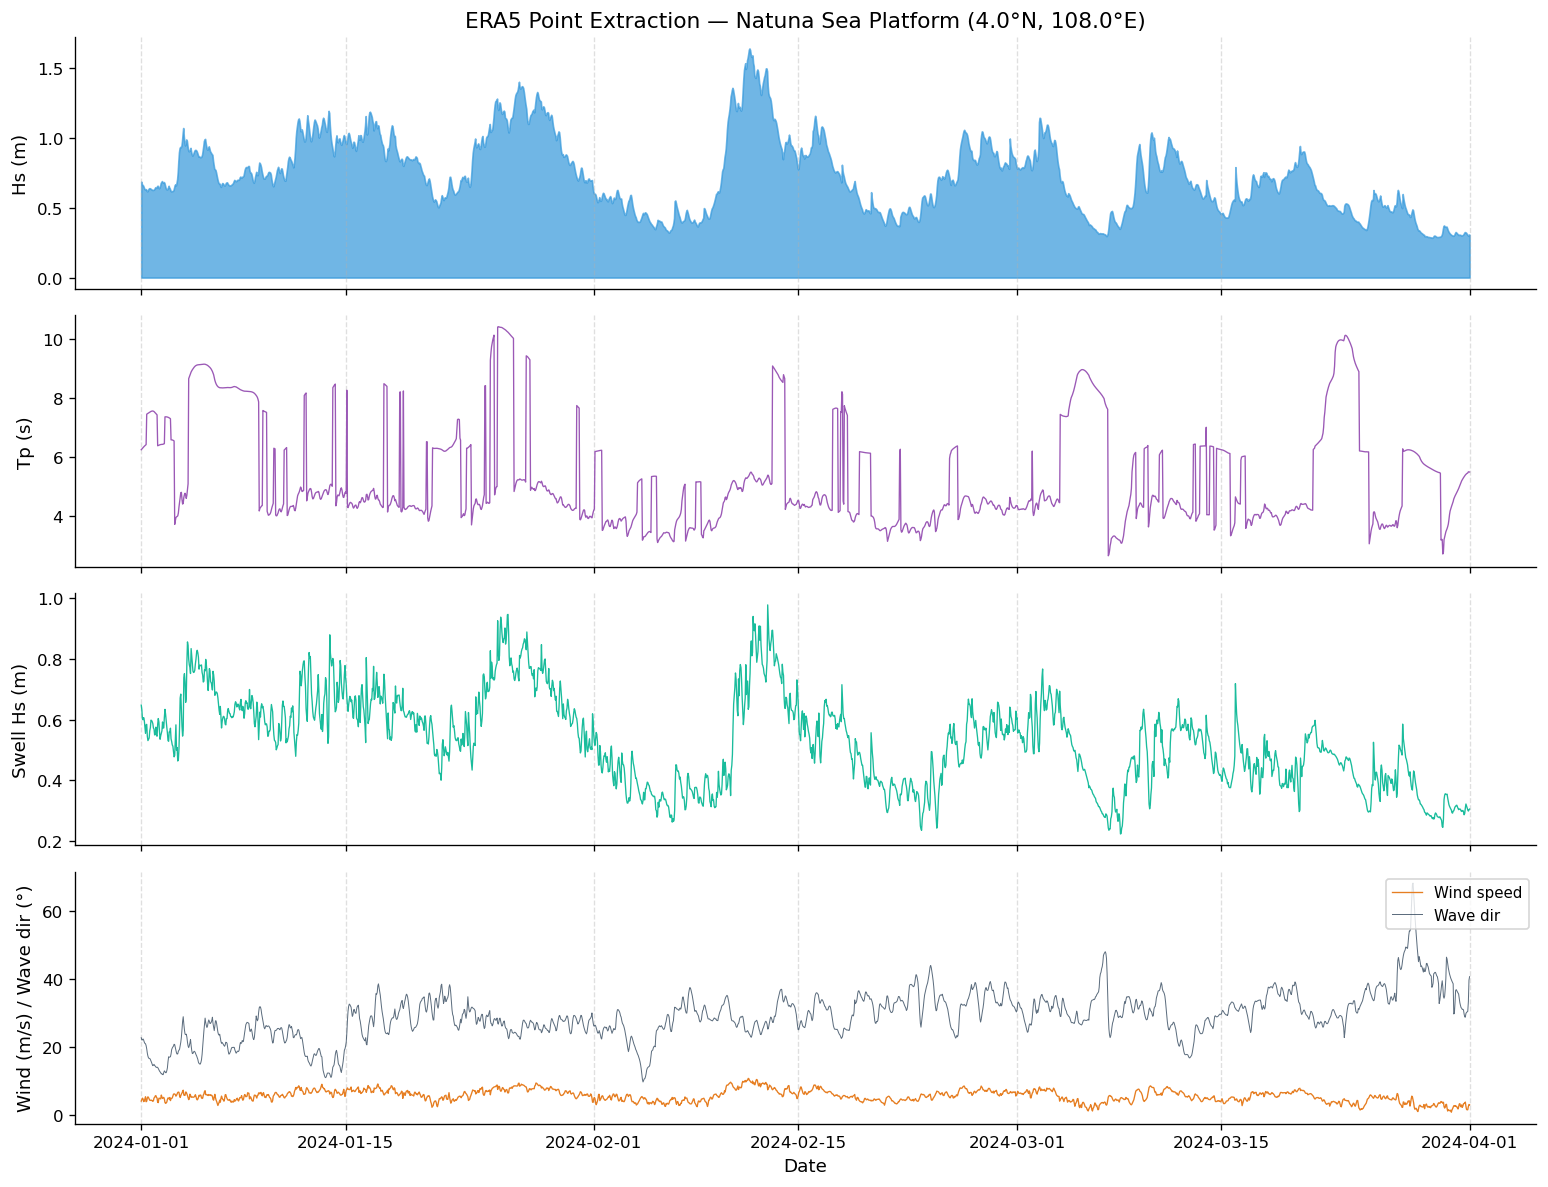

✅ Saved: timeseries_quicklook.png


In [10]:
# ── Quick-look time series — first 3 months ───────────────────
start = df.index.min()
sample = df[start : start + pd.DateOffset(months=3)]

fig, axes = plt.subplots(4, 1, figsize=(13, 10), sharex=True)

axes[0].fill_between(sample.index, sample["hs_m"], alpha=0.7, color="#3498db")
axes[0].set_ylabel("Hs (m)", fontsize=11)
axes[0].set_title(
    f"ERA5 Point Extraction — {SITE_NAME} ({TARGET_LAT}°N, {TARGET_LON}°E)",
    fontsize=13,
)

axes[1].plot(sample.index, sample["tp_s"], color="#9b59b6", lw=0.8)
axes[1].set_ylabel("Tp (s)", fontsize=11)

axes[2].plot(sample.index, sample["swell_hs_m"], color="#1abc9c", lw=0.8)
axes[2].set_ylabel("Swell Hs (m)", fontsize=11)

axes[3].plot(sample.index, sample["wind_speed_ms"], color="#e67e22", lw=0.8, label="Wind speed")
axes[3].plot(sample.index, sample["wave_dir_deg"], color="#34495e", lw=0.6, alpha=0.8, label="Wave dir")
axes[3].set_ylabel("Wind (m/s) / Wave dir (°)", fontsize=11)
axes[3].set_xlabel("Date", fontsize=11)
axes[3].legend(loc="upper right", fontsize=9)

for ax in axes:
    ax.grid(axis="x", linestyle="--", alpha=0.4)

fig.tight_layout()
plt.savefig("timeseries_quicklook.png", dpi=150)
plt.show()
print("✅ Saved: timeseries_quicklook.png")


### SECTION 5: Benchmark — The Performance Comparison

We compare **four extraction engines** on the same point:

| Engine | Pattern |
|--------|---------|
| Naive full load | `open_dataset` + `.values` — loads entire array |
| xarray lazy + sel | Default lazy open + nearest-neighbor |
| xarray + Dask | Chunked lazy open + parallel `.compute()` |
| xarray interp | Bilinear interpolation at sub-grid coords |

**5.1** runs a quick live demo on the teaching file (~120 MB). **5.2** shows pre-computed results on a larger ERA5 file — no multi-GB download required.

/home/yothunder/apps/nusawave-labs/extract-point/benchmarks/benchmark.py:102: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 500. This could degrade performance. Instead, consider rechunking after loading.
  lambda: xr.open_dataset(data_path, chunks=chunks)[wave_var]


Saved: benchmark_sample.csv
Saved: benchmark_sample.png


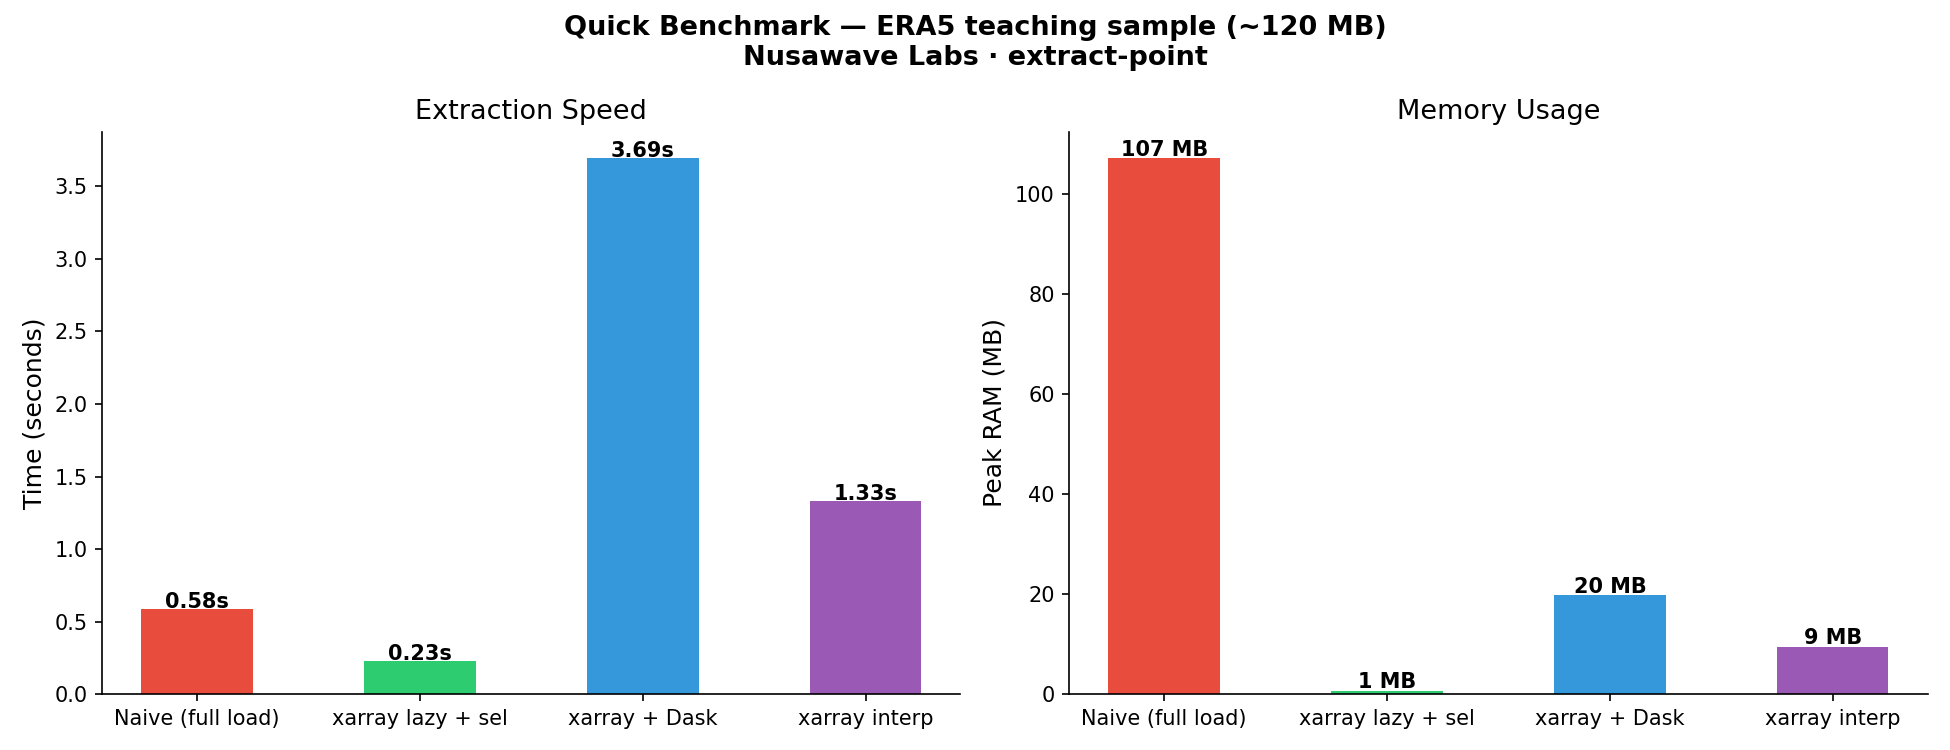

On our 120 MB file, lazy+sel already wins. At multi-GB scale the gap is dramatic — see below.


In [6]:
# @title 5.1 Quick live demo (teaching file — differences are modest)
import sys

sys.path.insert(0, str((REPO_ROOT / "benchmarks").resolve()))
from benchmark import run_benchmark, save_results

sample_results = run_benchmark(DATA_PATH, TARGET_LAT, TARGET_LON, verbose=False)
save_results(
    sample_results,
    csv_path=Path("benchmark_sample.csv"),
    png_path=Path("benchmark_sample.png"),
    title="Quick Benchmark — ERA5 teaching sample (~120 MB)\nNusawave Labs · extract-point",
)

from IPython.display import Image, display

display(Image(filename="benchmark_sample.png"))
print("On our 120 MB file, lazy+sel already wins. At multi-GB scale the gap is dramatic — see below.")


#### 5.2 At realistic scale (pre-computed — no download)

These charts were generated by maintainers on a larger ERA5 file using [`benchmarks/generate_assets.py`](../benchmarks/generate_assets.py). You only view the results — the heavy work already ran.

| Dataset | Approx. size | Location | Grid |
|---------|-------------|----------|------|
| ERA5 reanalysis | ~0.1–2 GB | Natuna Sea (4°N, 108°E) | 20×20, multi-year |

── ERA5 reanalysis (large file) ──


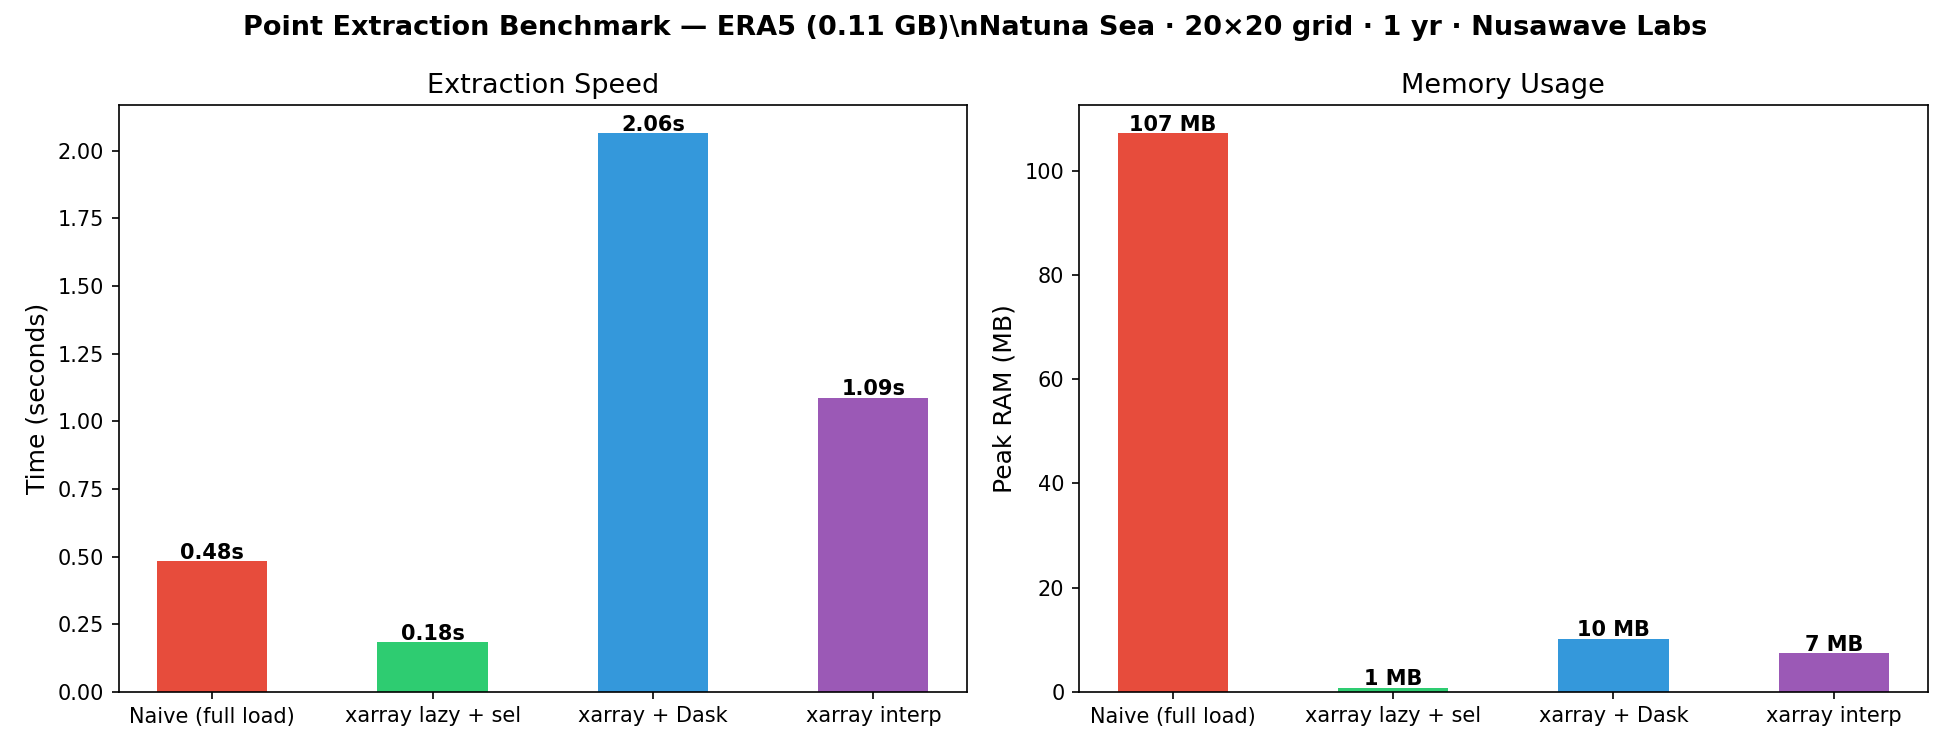

,time_s,peak_mb
Naive (full load),0.48,107.13
xarray lazy + sel,0.18,0.78
xarray + Dask,2.06,10.23
xarray interp,1.09,7.41


In [7]:
# @title 5.2 Pre-computed benchmark charts
from IPython.display import Image, display

BENCHMARK_DIR = REPO_ROOT / "data" / "benchmark"
png = BENCHMARK_DIR / "era5_large_benchmark.png"
csv = BENCHMARK_DIR / "era5_large_benchmark.csv"

if not png.exists():
    print("⚠️  Missing era5_large_benchmark.png — maintainer: python3 benchmarks/generate_assets.py")
else:
    print("── ERA5 reanalysis (large file) ──")
    display(Image(filename=png))
    display(pd.read_csv(csv, index_col=0).round(2))

## What This Chart Tells You

| Method | ~Time | Peak RAM | Use When |
|---|---|---|---|
| Naive full load | Slowest | Highest | Never, for large files |
| xarray lazy+sel | Fast | Low | Default choice, always |
| xarray+Dask | Moderate overhead | Low | Files > 1GB, multi-core |
| xarray interp | ~Same as sel | Low | Site-specific precision needed |

🔑 Key insight: The "lazy" approach isn't just faster —
it scales. On a 40GB multi-year file, naive loading
crashes your machine. Lazy+sel still works in seconds.


### SECTION 7: Site Statistics

In [15]:
print("═" * 45)
print(f"  SITE STATISTICS — {SITE_NAME}")
print(f"  {df.index[0].date()} to {df.index[-1].date()}")
print("═" * 45)
for var in ["hs_m", "tp_s", "wave_dir_deg", "swell_hs_m", "swell_dir_deg", "swell_tp_s", "wind_speed_ms"]:
    s = quick_stats(df, var)
    print(f"\n  {var}")
    print(f"    Mean ± Std : {s['mean']:.2f} ± {s['std']:.2f}")
    print(f"    P90 / P99  : {s['p90']:.2f} / {s['p99']:.2f}")
    print(f"    Max        : {s['max']:.2f}")
print("═" * 45)


═════════════════════════════════════════════
  SITE STATISTICS — Natuna Sea Platform
  2024-01-01 to 2024-12-31
═════════════════════════════════════════════

  hs_m
    Mean ± Std : 0.59 ± 0.30
    P90 / P99  : 1.00 / 1.49
    Max        : 2.61

  tp_s
    Mean ± Std : 5.22 ± 2.10
    P90 / P99  : 9.06 / 10.87
    Max        : 11.10

  wave_dir_deg
    Mean ± Std : 127.96 ± 104.87
    P90 / P99  : 266.44 / 351.49
    Max        : 359.63

  swell_hs_m
    Mean ± Std : 0.45 ± 0.18
    P90 / P99  : 0.68 / 0.92
    Max        : 1.58

  swell_dir_deg
    Mean ± Std : 126.24 ± 109.48
    P90 / P99  : 278.16 / 351.42
    Max        : 359.76

  swell_tp_s
    Mean ± Std : 4.83 ± 1.21
    P90 / P99  : 6.56 / 7.93
    Max        : 8.92

  wind_speed_ms
    Mean ± Std : 4.25 ± 2.20
    P90 / P99  : 7.24 / 9.46
    Max        : 12.97
═════════════════════════════════════════════


### SECTION 6: What's Next

##### You Just Learned:

- ✅ Why NetCDF files crash laptops (eager loading)
- ✅ How lazy loading works (xarray's superpower)
- ✅ Three extraction methods + when to use each
- ✅ How to export a clean time series CSV

##### What Real Engineers Do Next With This Data:
- Wave statistics & exceedance curves
- Extreme value analysis for design criteria
- Joint extremes for offshore structure design

Follow Nusawave on [LinkedIn](https://www.linkedin.com/company/109905023)

Star this repo on [GitHub](https://github.com/nusawave-labs/extract-point)
